# Nama: Rayhan Ahmad
# NIM: 4222301078
# Kelas: Robotika 6C Pagi

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [ ]:
df = pd.read_csv('WineQT.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai fixed acidity vs volatile acidity')

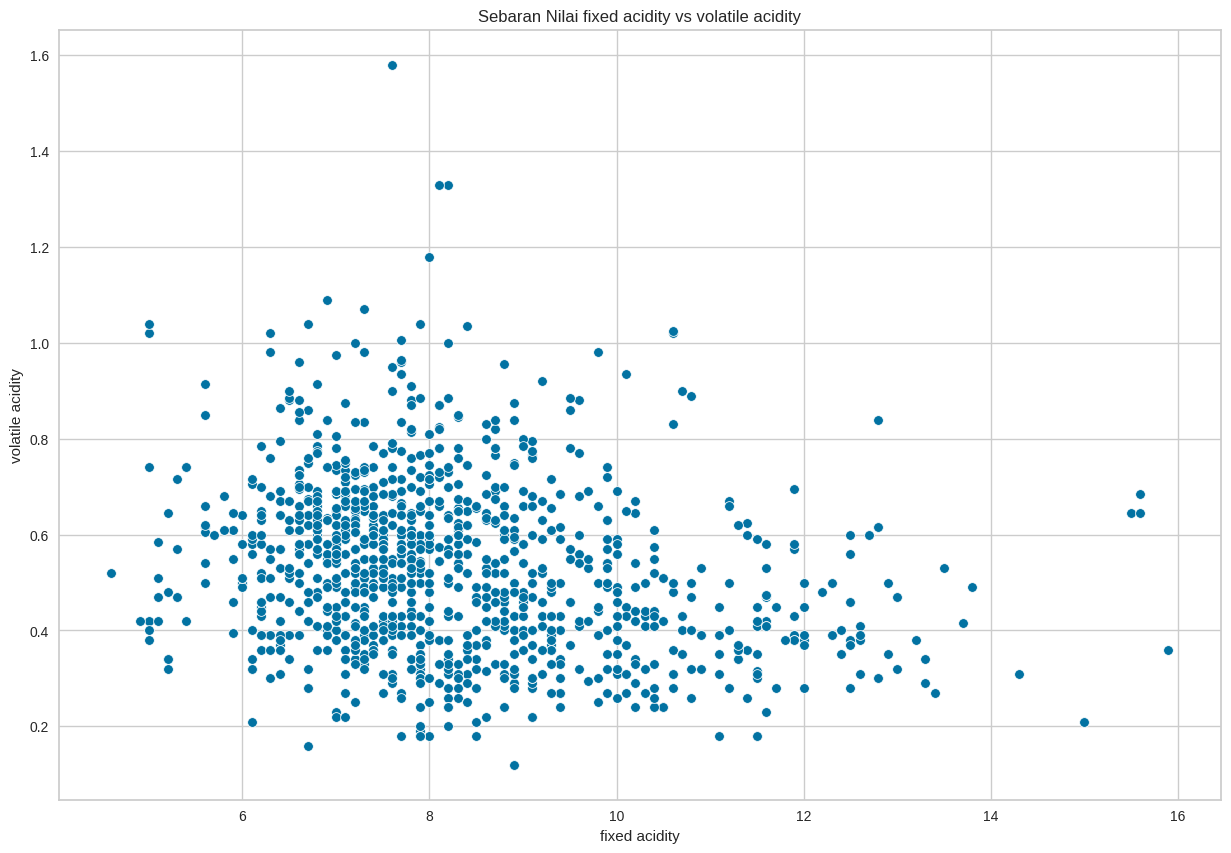

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='volatile acidity')
plt.title('Sebaran Nilai fixed acidity vs volatile acidity')

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


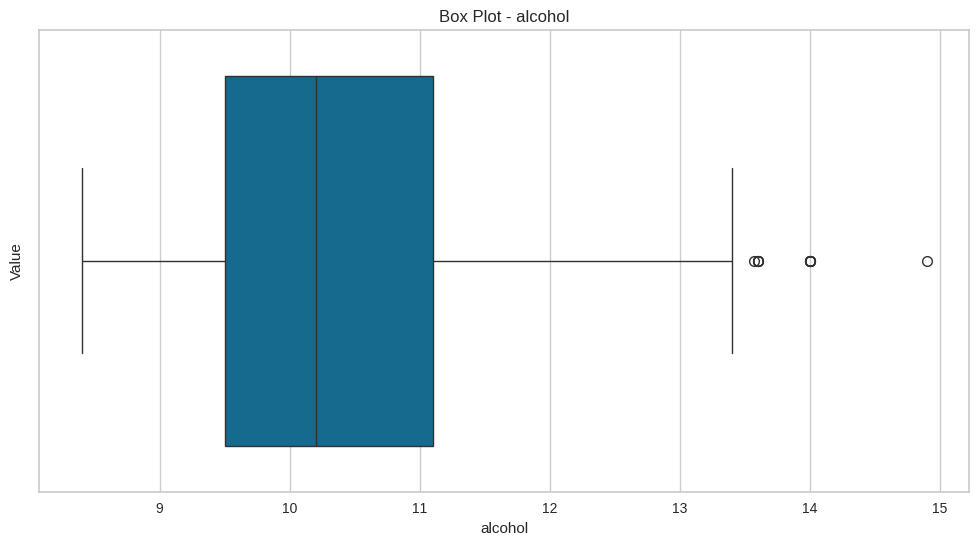

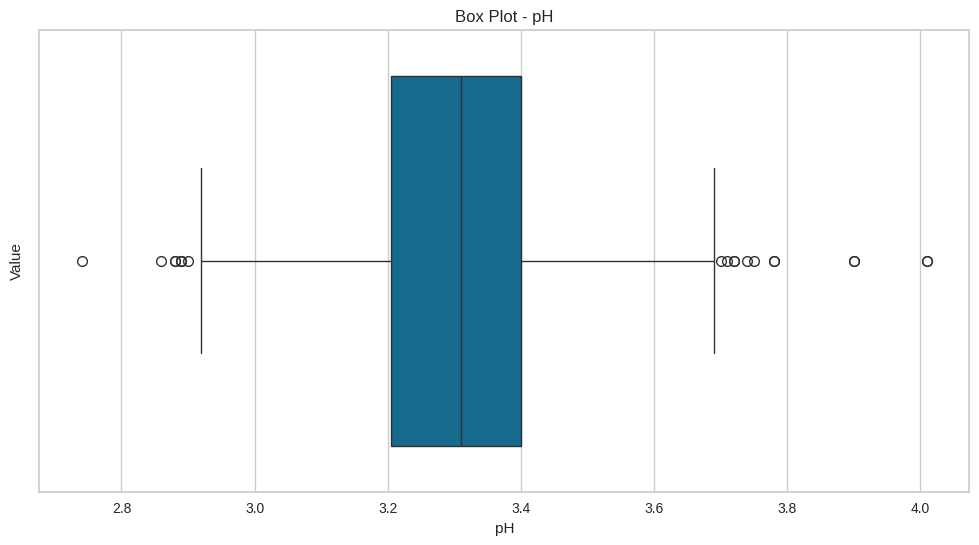

In [ ]:
# Looping for 'alcohol' and 'pH' columns
columns = ['alcohol', 'pH']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Value')
    plt.show()

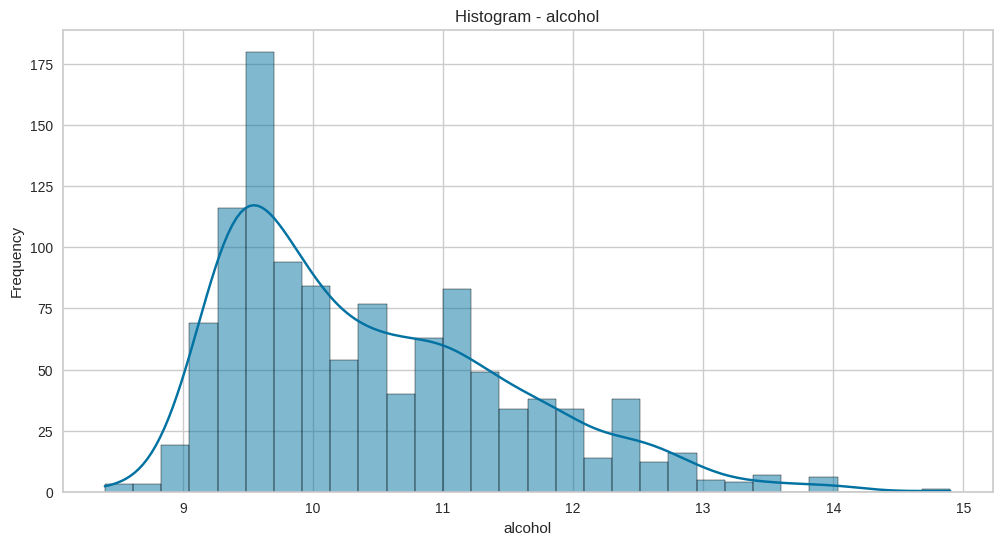

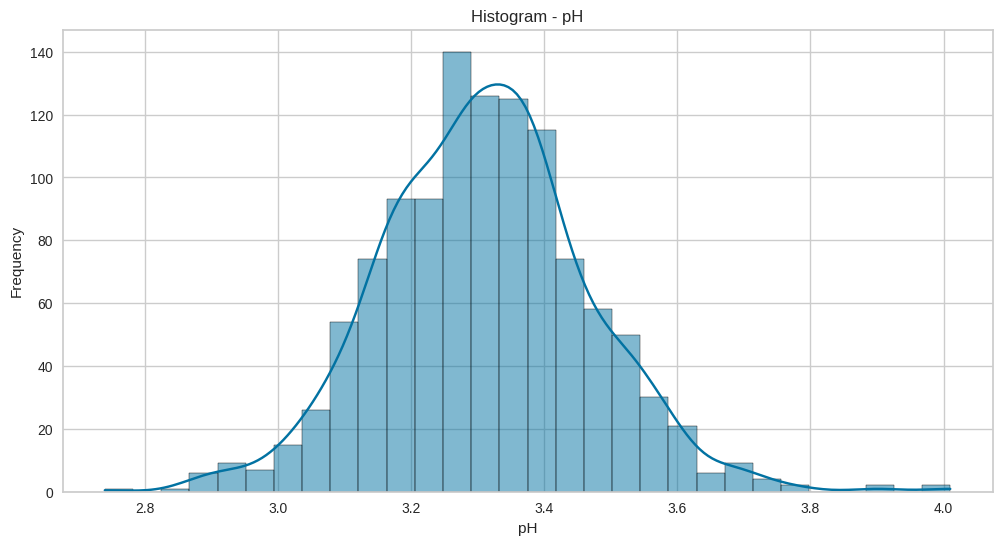

In [ ]:
columns = ['alcohol', 'pH']

for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [ ]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [ ]:
fitur_columns = ['alcohol', 'pH']
X = df[fitur_columns].values
# y = df['deskripsi'].values #anotator label - Removed as 'deskripsi' column is not in the dataset

In [ ]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler

# Print the columns being scaled to ensure correctness
print(f"Scaling columns: {fitur_columns}")

X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

Scaling columns: ['alcohol', 'pH']


,alcohol,pH
count,1.143000e+03,1.143000e+03
mean,-1.193563e-15,-8.454402e-16
std,1.000438e+00,1.000438e+00
min,-1.887834e+00,-3.646432e+00
25%,-8.709366e-01,-6.769982e-01
50%,-2.238203e-01,-6.480857e-03
75%,6.081863e-01,5.682483e-01
max,4.121103e+00,4.463634e+00


In [ ]:
X_std

array([[-0.96338181,  1.27069495],
       [-0.59360107, -0.70892755],
       [-0.59360107, -0.32577481],
       ...,
       [ 0.05351522,  0.88754221],
       [ 0.70063152,  1.33455374],
       [-0.22382033,  1.65384769]])

In [ ]:
df_scalling

,alcohol,pH
0,-0.963382,1.270695
1,-0.593601,-0.708928
2,-0.593601,-0.325775
3,-0.593601,-0.964363
4,-0.963382,1.270695
...,...,...
1138,0.515741,0.695966
1139,-0.870937,0.695966
1140,0.053515,0.887542
1141,0.700632,1.334554


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

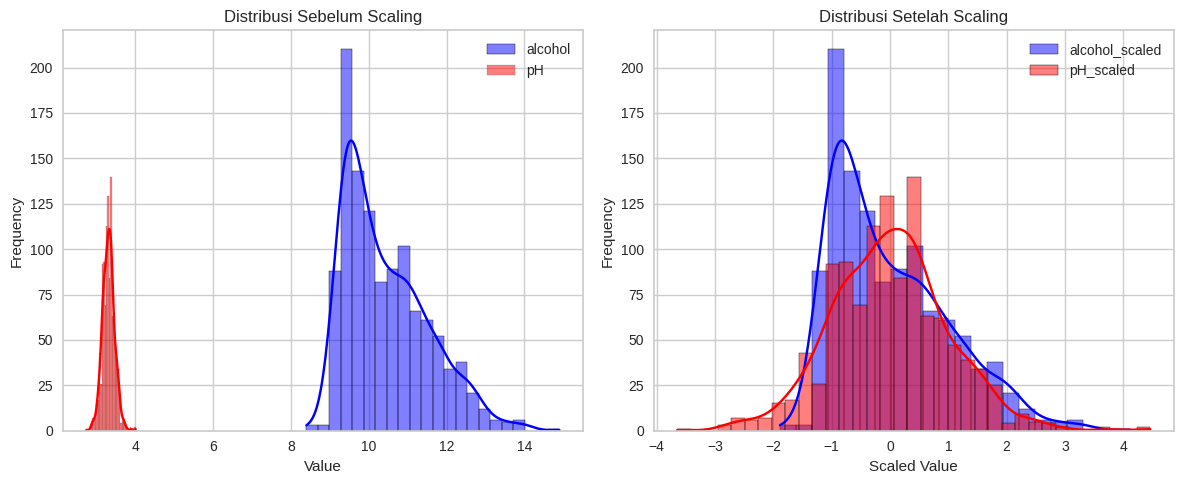

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler
sns.histplot(df['alcohol'], ax=ax1, color='blue', label='alcohol', kde=True)
sns.histplot(df['pH'], ax=ax1, color='red', label='pH', kde=True)
ax1.set_title('Distribusi Sebelum Scaling')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')
ax1.legend()

# Plot distribusi setelah Standar Scaler
sns.histplot(df_scalling['alcohol'], ax=ax2, color='blue', label='alcohol_scaled', kde=True)
sns.histplot(df_scalling['pH'], ax=ax2, color='red', label='pH_scaled', kde=True)
ax2.set_title('Distribusi Setelah Scaling')
ax2.set_xlabel('Scaled Value')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
Berdasarkan grafik distribusi sebelum dan sesudah Standard Scaler, terlihat bahwa proses scaling berhasil mengubah rentang nilai pada fitur alcohol dan pH menjadi lebih terstandarisasi.

Sebelum scaling, nilai alcohol dan pH memiliki rentang dan skala yang berbeda sehingga distribusi data terlihat tidak seimbang. Setelah dilakukan Standard Scaler, distribusi kedua fitur menjadi lebih terpusat di sekitar nilai 0 dengan penyebaran data yang lebih seragam.

Proses scaling tidak mengubah bentuk pola distribusi data, tetapi hanya menyesuaikan skala nilainya. Hal ini penting dalam machine learning karena dapat membantu algoritma bekerja lebih optimal, terutama algoritma yang sensitif terhadap perbedaan skala fitur seperti KNN, SVM, dan Logistic Regression.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

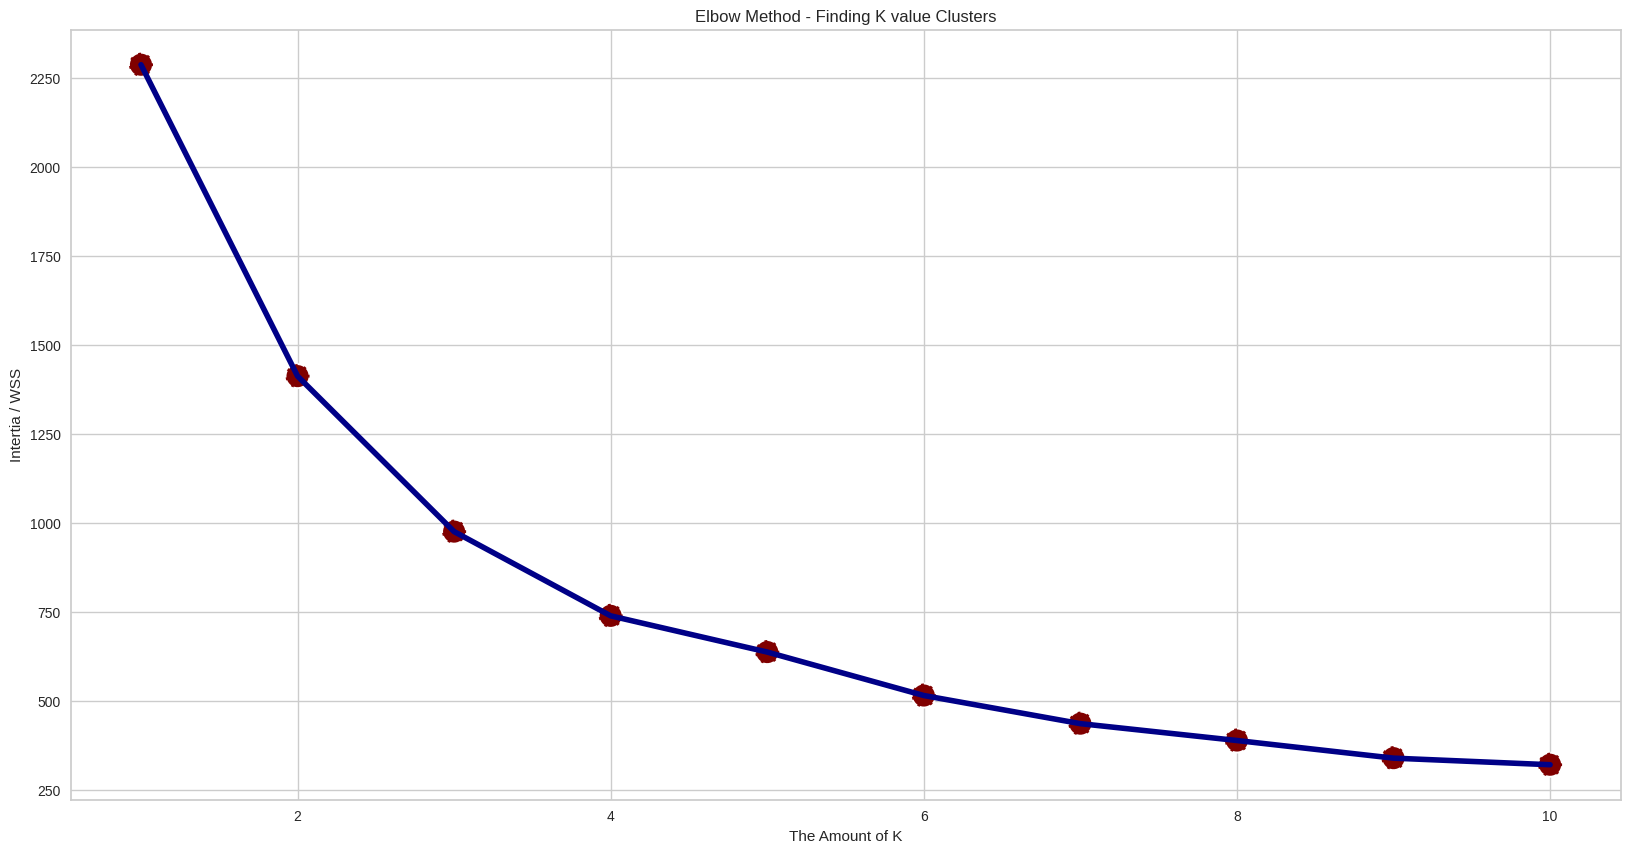

In [ ]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [ ]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [ ]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3


Text(0.5, 1.0, 'K-Means Clustering (Elbow Method) - Alcohol vs pH')

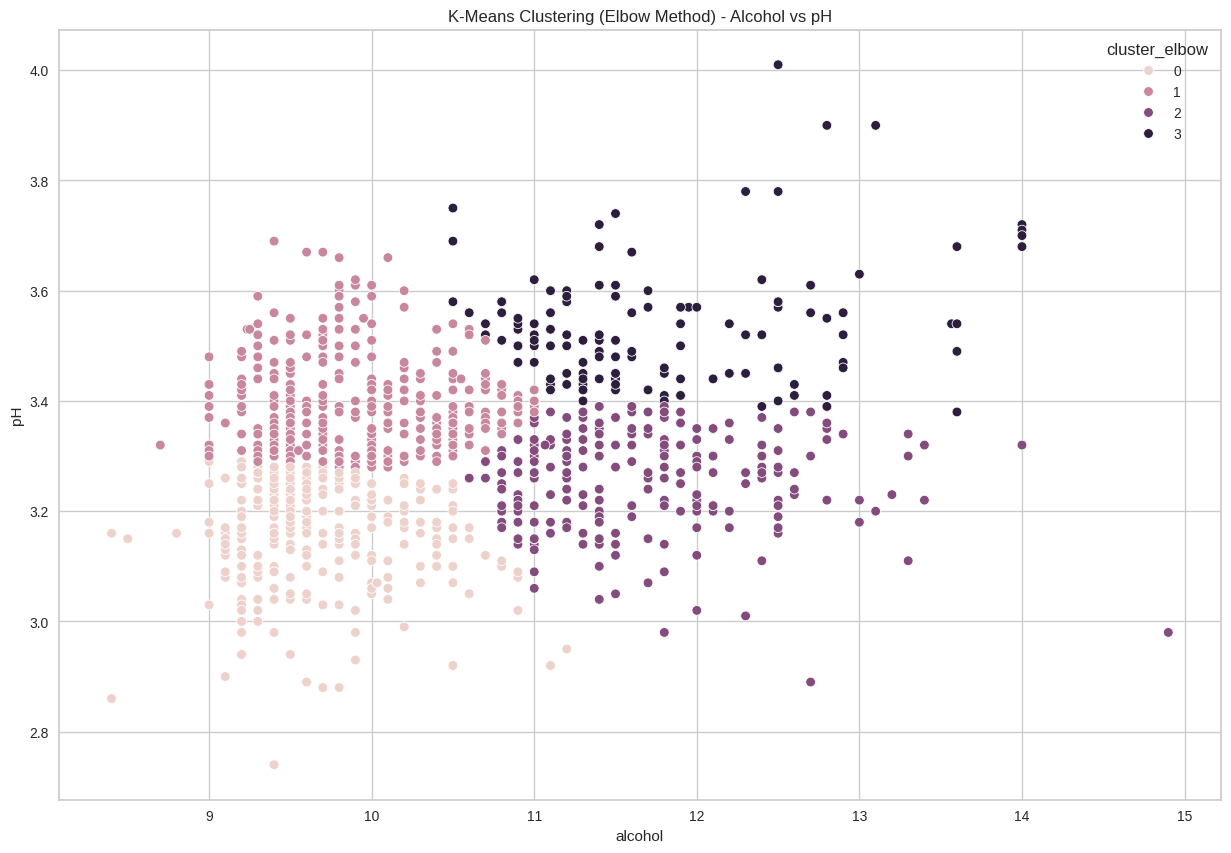

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='pH', hue='cluster_elbow')
plt.title('K-Means Clustering (Elbow Method) - Alcohol vs pH')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='pH', ylabel='alcohol'>

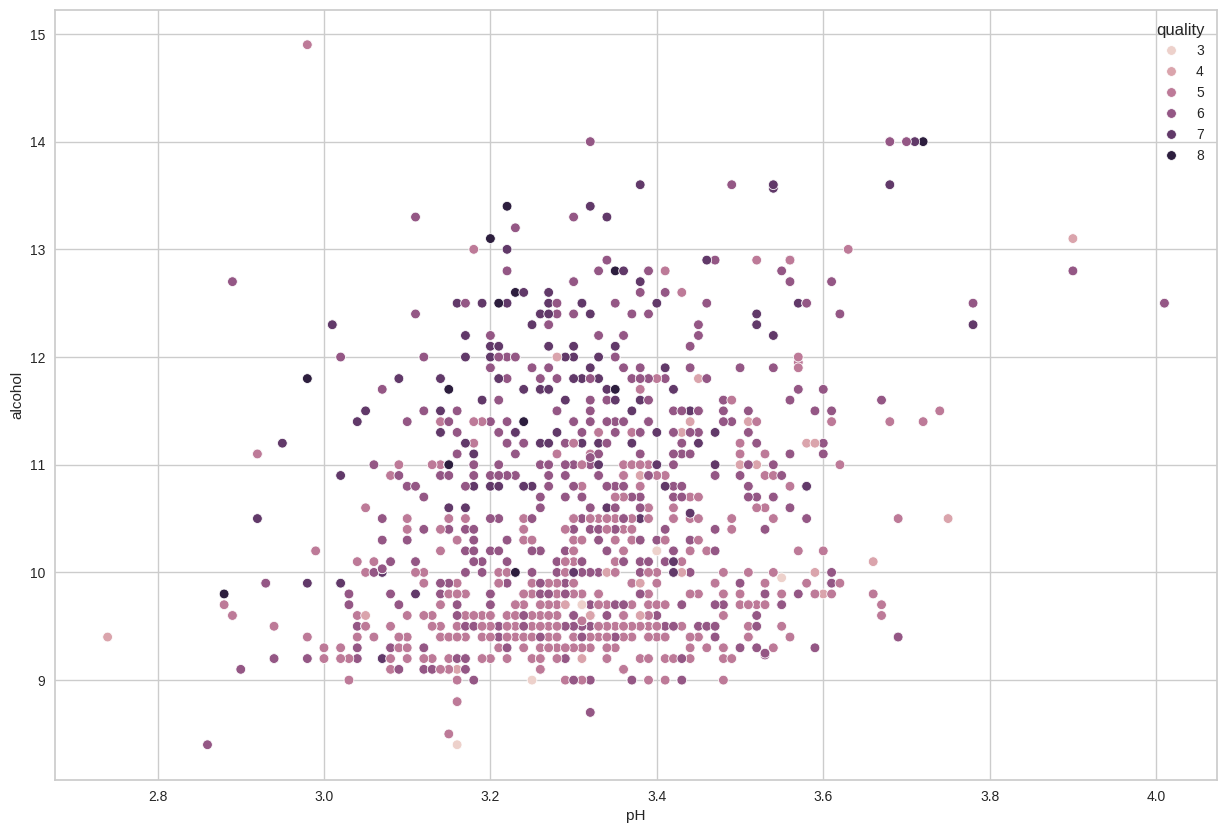

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='pH', y='alcohol',hue='quality')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Quality 3 dan 4
2. Cluster 1 -> Quality 5
3. Cluster 2 -> Quality 6
4. Cluster 3 -> Quality 7 dan 8

### 2. Via Score Plot

In [ ]:
!pip install yellowbrick

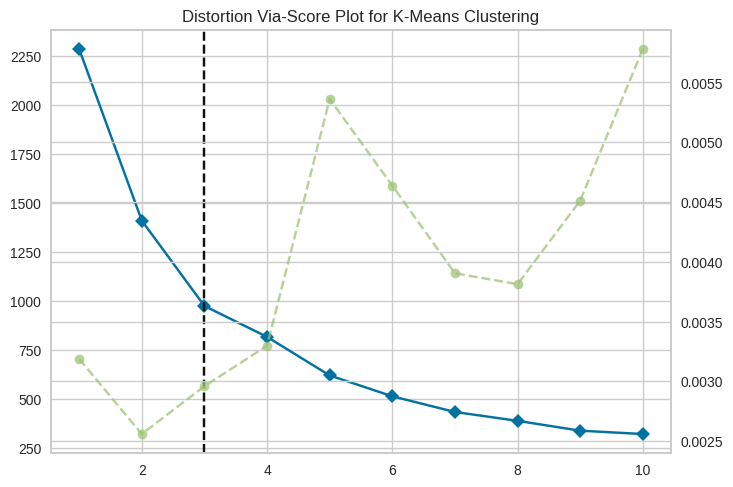

In [ ]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [ ]:
# Dari hasil diatas K-nya dipilih pada angka 4,
# karena titik distorsinya bertemu pada nilai 4 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=4, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [ ]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3,3


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

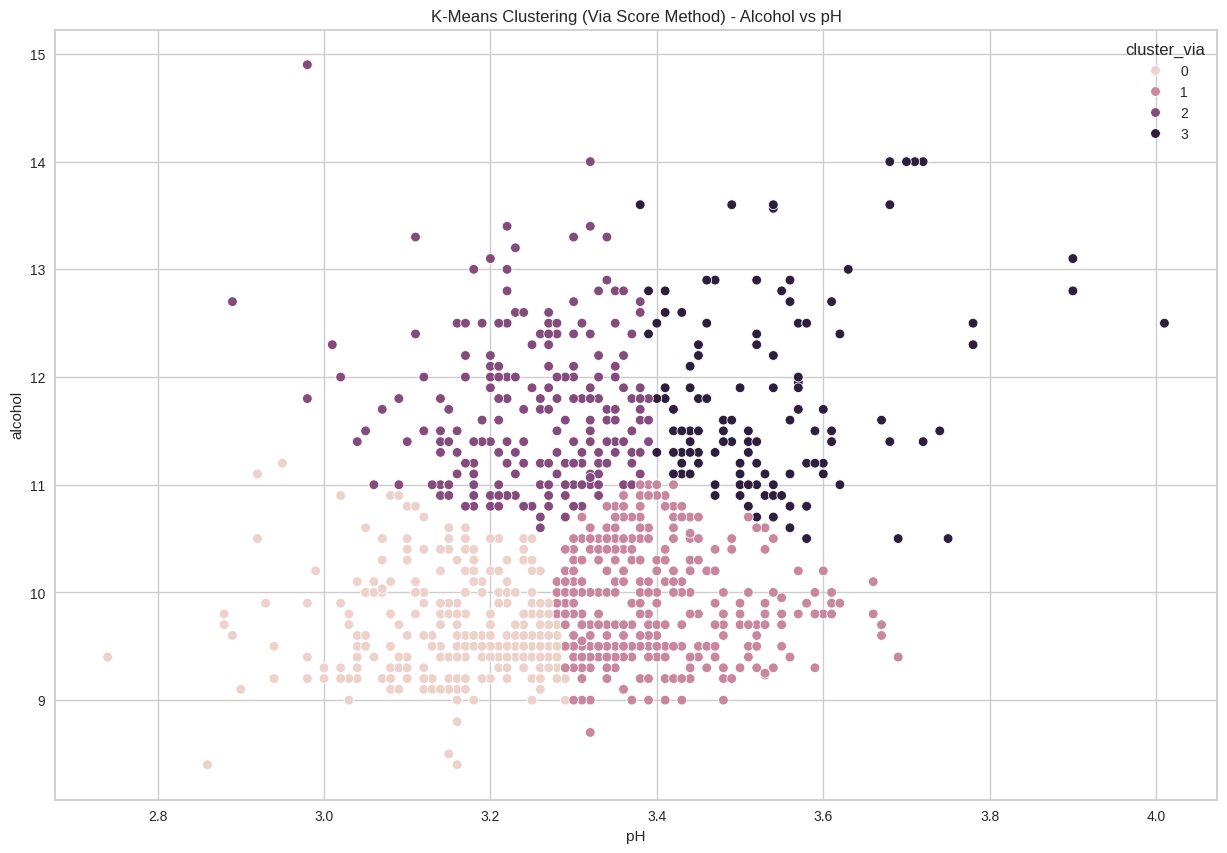

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='pH', y='alcohol', hue='cluster_via')
plt.title('K-Means Clustering (Via Score Method) - Alcohol vs pH')
plt.show()

### Bandingkan dengan label anotator

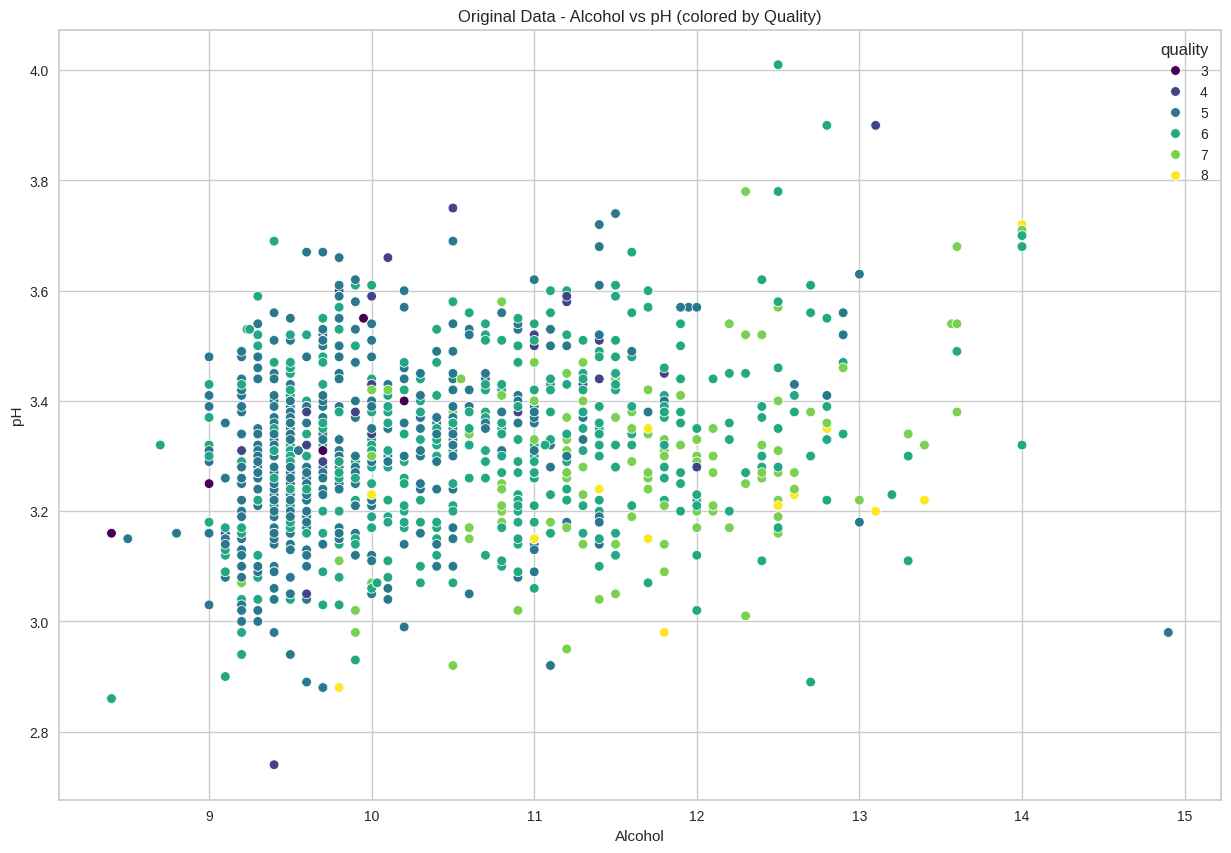

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='pH', hue='quality', palette='viridis')
plt.title('Original Data - Alcohol vs pH (colored by Quality)')
plt.xlabel('Alcohol')
plt.ylabel('pH')
plt.show()

Tulis Interpretasi dari hasil evaluasi diatas :

Optimal Jumlah Cluster (K):
Baik metode Elbow maupun Via Score Plot menunjukkan bahwa jumlah cluster yang optimal adalah K = 3. Pada metode Elbow, titik siku (elbow) terlihat paling jelas pada K = 3, yang menandakan bahwa penambahan cluster setelah titik tersebut tidak memberikan penurunan inersia yang signifikan. Hal serupa juga terlihat pada Via Score Plot, di mana nilai evaluasi menunjukkan hasil terbaik pada K = 3.

Perbandingan dengan Label 'Quality':
Ketika hasil clustering K-Means dibandingkan dengan data asli yang diwarnai berdasarkan label quality, terlihat bahwa pola persebaran cluster memiliki kemiripan dengan distribusi kualitas wine. Data dengan kadar alcohol rendah dan pH tertentu cenderung berada pada cluster yang sama, sedangkan data dengan alcohol lebih tinggi membentuk cluster berbeda.

Meskipun demikian, karena K-Means merupakan metode unsupervised learning, label cluster seperti 0, 1, dan 2 tidak secara langsung merepresentasikan nilai quality tertentu seperti 3, 4, 5, 6, 7, atau 8. Oleh karena itu, interpretasi cluster dilakukan berdasarkan karakteristik fitur dalam masing-masing cluster, bukan berdasarkan nomor cluster.

Karakteristik Cluster:
1. Cluster 0 -> Didominasi wine dengan kadar alcohol rendah dan pH normal hingga rendah.
2. Cluster 1 -> Didominasi wine dengan kadar alcohol menengah dan persebaran pH yang cukup stabil.
3. Cluster 2 -> Didominasi wine dengan kadar alcohol tinggi dan variasi pH yang lebih luas.

Secara keseluruhan, hasil clustering menunjukkan bahwa fitur alcohol dan pH memiliki hubungan terhadap kualitas wine dan mampu digunakan untuk memisahkan pola data menjadi beberapa kelompok yang cukup baik, walaupun masih terdapat overlap antar cluster.

### Thank you :)